# Loan Default Risk Prediction Mode (Logistic Regression)

# Problem Statement
 - The objective of this project is to develop a machine learning classification model that predicts whether a borrower is likely to default on a loan based on various demographic, financial, and credit-related factors such as age, annual income, credit score, loan amount, employment history, number of credit lines, debt-to-income ratio, payment history, savings balance, and loan purpose

# 📈 Workflow Architecture

# 📊 Data Structure

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Loading Dataset

In [ ]:
df=pd.read_csv("Bank.csv")
df

,age,annual_income,credit_score,loan_amount,employment_years,num_credit_lines,debt_to_income_ratio,missed_payments_last_2yrs,savings_balance,loan_purpose,defaulted
0,61,34531,720,6187,6.0,8,0.532,2,2589,personal,Yes
1,39,55561,587,23644,5.8,2,0.474,3,878,personal,Yes
2,48,48020,593,10165,5.2,3,0.601,No,2939,education,Yes
3,53,42576,720,23311,6.8,14,0.329,2,6916,education,Yes
4,33,120979,616,6338,0.7,11,0.302,No,790,education,No
...,...,...,...,...,...,...,...,...,...,...,...
995,52,52847,841,6301,10.1,8,0.203,No,19565,personal,No
996,24,93450,808,1194,12.2,8,0.351,No,18706,home,No
997,50,25830,618,1000,5.1,3,0.467,2,435,auto,Yes
998,34,80284,706,11992,7.1,13,0.230,No,12068,home,No


# Data Understanding

In [3]:
df.head()

,age,annual_income,credit_score,loan_amount,employment_years,num_credit_lines,debt_to_income_ratio,missed_payments_last_2yrs,savings_balance,loan_purpose,defaulted
0,61,34531,720,6187,6.0,8,0.532,2,2589,personal,Yes
1,39,55561,587,23644,5.8,2,0.474,3,878,personal,Yes
2,48,48020,593,10165,5.2,3,0.601,No,2939,education,Yes
3,53,42576,720,23311,6.8,14,0.329,2,6916,education,Yes
4,33,120979,616,6338,0.7,11,0.302,No,790,education,No


In [4]:
df.tail()

,age,annual_income,credit_score,loan_amount,employment_years,num_credit_lines,debt_to_income_ratio,missed_payments_last_2yrs,savings_balance,loan_purpose,defaulted
995,52,52847,841,6301,10.1,8,0.203,No,19565,personal,No
996,24,93450,808,1194,12.2,8,0.351,No,18706,home,No
997,50,25830,618,1000,5.1,3,0.467,2,435,auto,Yes
998,34,80284,706,11992,7.1,13,0.230,No,12068,home,No
999,44,64523,674,13449,15.2,5,0.367,No,12768,personal,No


In [5]:
df.shape

(1000, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age                        1000 non-null   int64  
 1   annual_income              1000 non-null   int64  
 2   credit_score               1000 non-null   int64  
 3   loan_amount                1000 non-null   int64  
 4   employment_years           1000 non-null   object 
 5   num_credit_lines           1000 non-null   object 
 6   debt_to_income_ratio       1000 non-null   float64
 7   missed_payments_last_2yrs  1000 non-null   object 
 8   savings_balance            1000 non-null   object 
 9   loan_purpose               1000 non-null   object 
 10  defaulted                  1000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 86.1+ KB


In [7]:
df.describe()

,age,annual_income,credit_score,loan_amount,debt_to_income_ratio
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,42.824000,51653.366000,644.056000,12228.493000,0.414930
std,12.472794,20690.878159,91.900994,6560.603789,0.171401
min,22.000000,10000.000000,366.000000,1000.000000,0.050000
25%,32.000000,36247.500000,581.750000,7304.750000,0.281750
50%,43.000000,49587.000000,646.000000,12081.500000,0.399000
75%,54.000000,66600.000000,711.250000,16654.500000,0.545250
max,64.000000,121479.000000,850.000000,35899.000000,0.939000


In [8]:
df.dtypes

age                            int64
annual_income                  int64
credit_score                   int64
loan_amount                    int64
employment_years              object
num_credit_lines              object
debt_to_income_ratio         float64
missed_payments_last_2yrs     object
savings_balance               object
loan_purpose                  object
defaulted                     object
dtype: object

# Detect and replace correct data tyep

In [9]:
df['employment_years'].values # it convert columns into array (just to see all values from columns)

array(['6.0', '5.8', '5.2', '6.8', '0.7', '6.9', '7.1', '5.2', '4.9',
       '7.6', '2.2', '11.8', 'No', '2.2', 'No', '4.6', '13.5', '6.3',
       '2.1', '10.4', '6.1', '0.7', '3.6', '2.7', '5.1', '10.4', '15.0',
       '3.8', '4.5', '4.5', '6.6', '6.4', '4.8', '6.6', '6.0', '8.7',
       '3.9', '3.9', '2.4', '17.4', '10.0', '4.8', '9.7', '6.1', '1.6',
       '5.5', '5.2', 'No', '8.1', '1.4', '1.2', 'No', '5.8', 'No', '8.1',
       '2.8', '2.8', '11.0', '19.8', '3.2', '9.3', '12.0', 'No', '3.8',
       '6.2', '4.3', 'No', '7.4', '4.7', '4.5', '4.8', '8.7', '1.2',
       '1.1', '5.1', '8.3', '0.4', '4.7', '3.6', '9.0', '4.6', '6.4',
       '9.2', '2.1', 'No', '8.8', '2.7', '5.0', '2.8', '6.0', '4.6',
       '2.9', 'No', '10.5', 'No', '9.8', '1.4', '13.9', '8.5', '1.6',
       'No', '8.0', 'No', '9.3', '1.6', '2.0', '0.2', '1.8', 'No', '4.8',
       '6.7', 'No', 'No', '3.2', '9.9', '2.6', '4.1', '4.9', '8.1', '8.1',
       '0.6', '3.1', '3.8', '8.4', '3.6', 'No', '9.1', '6.2', '2.2',
   

In [10]:
pd.to_numeric(df['employment_years'],errors='coerce').values  # error means whatever error are find when converting into numericit will sho

array([ 6. ,  5.8,  5.2,  6.8,  0.7,  6.9,  7.1,  5.2,  4.9,  7.6,  2.2,
       11.8,  nan,  2.2,  nan,  4.6, 13.5,  6.3,  2.1, 10.4,  6.1,  0.7,
        3.6,  2.7,  5.1, 10.4, 15. ,  3.8,  4.5,  4.5,  6.6,  6.4,  4.8,
        6.6,  6. ,  8.7,  3.9,  3.9,  2.4, 17.4, 10. ,  4.8,  9.7,  6.1,
        1.6,  5.5,  5.2,  nan,  8.1,  1.4,  1.2,  nan,  5.8,  nan,  8.1,
        2.8,  2.8, 11. , 19.8,  3.2,  9.3, 12. ,  nan,  3.8,  6.2,  4.3,
        nan,  7.4,  4.7,  4.5,  4.8,  8.7,  1.2,  1.1,  5.1,  8.3,  0.4,
        4.7,  3.6,  9. ,  4.6,  6.4,  9.2,  2.1,  nan,  8.8,  2.7,  5. ,
        2.8,  6. ,  4.6,  2.9,  nan, 10.5,  nan,  9.8,  1.4, 13.9,  8.5,
        1.6,  nan,  8. ,  nan,  9.3,  1.6,  2. ,  0.2,  1.8,  nan,  4.8,
        6.7,  nan,  nan,  3.2,  9.9,  2.6,  4.1,  4.9,  8.1,  8.1,  0.6,
        3.1,  3.8,  8.4,  3.6,  nan,  9.1,  6.2,  2.2,  3. ,  1.4,  7.2,
       11.6,  2.5,  nan,  7.1,  6.7,  6. ,  9. , 13.7,  9. , 12.6,  0.3,
        5.7,  0.1,  5.9,  nan, 15.3,  6.4,  6.6,  2

In [11]:
df['employment_years'][pd.to_numeric(df['employment_years'],errors='coerce').isna()].unique()

array(['No', 'Yes'], dtype=object)

In [12]:
df['num_credit_lines'][pd.to_numeric(df['num_credit_lines'],errors='coerce').isna()].unique()

array(['Yes'], dtype=object)

In [13]:
wrong_dtype=df[['employment_years','num_credit_lines','missed_payments_last_2yrs','savings_balance'] ]

In [14]:
for i in wrong_dtype:
    print(f'{i} = {df[i][pd.to_numeric(df[i],errors='coerce').isna()].unique()}')

employment_years = ['No' 'Yes']
num_credit_lines = ['Yes']
missed_payments_last_2yrs = ['No' 'Yes']
savings_balance = ['No']


In [15]:
for i in df.columns:
    invalid=df[i][pd.to_numeric(df[i],errors='coerce').isna()].unique()
    if len(invalid)>0:
        print(f'{i} = {invalid}')

employment_years = ['No' 'Yes']
num_credit_lines = ['Yes']
missed_payments_last_2yrs = ['No' 'Yes']
savings_balance = ['No']
loan_purpose = ['personal' 'education' 'home' 'auto']
defaulted = ['Yes' 'No']


In [16]:
df['missed_payments_last_2yrs'].value_counts()

missed_payments_last_2yrs
No     497
Yes    254
2      152
4       49
3       48
Name: count, dtype: int64

In [17]:
df[['employment_years','num_credit_lines',
    'missed_payments_last_2yrs','savings_balance','defaulted']]=df[['employment_years','num_credit_lines',
    'missed_payments_last_2yrs','savings_balance','defaulted']].replace(['Yes','No'],[1,0])

In [18]:
df['missed_payments_last_2yrs'].value_counts()

missed_payments_last_2yrs
0    497
1    254
2    152
4     49
3     48
Name: count, dtype: int64

# Data Quality Check

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.isna().sum()

age                          0
annual_income                0
credit_score                 0
loan_amount                  0
employment_years             0
num_credit_lines             0
debt_to_income_ratio         0
missed_payments_last_2yrs    0
savings_balance              0
loan_purpose                 0
defaulted                    0
dtype: int64

# EDA

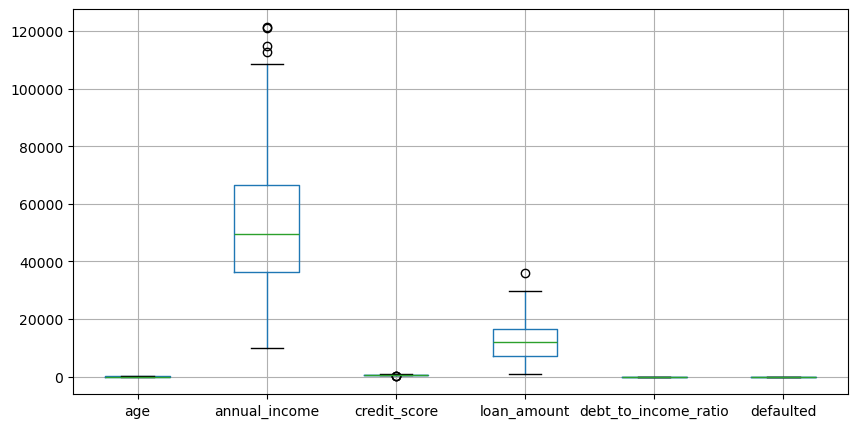

In [21]:
plt.figure(figsize=(10,5))
df.boxplot()
plt.show()

# Encoding

In [22]:
oe=OrdinalEncoder()
le=LabelEncoder()
df['loan_purpose']=oe.fit_transform(df[['loan_purpose']])
df['defaulted']=le.fit_transform(df['defaulted'])

In [23]:
df.head()

,age,annual_income,credit_score,loan_amount,employment_years,num_credit_lines,debt_to_income_ratio,missed_payments_last_2yrs,savings_balance,loan_purpose,defaulted
0,61,34531,720,6187,6.0,8,0.532,2,2589,3.0,1
1,39,55561,587,23644,5.8,2,0.474,3,878,3.0,1
2,48,48020,593,10165,5.2,3,0.601,0,2939,1.0,1
3,53,42576,720,23311,6.8,14,0.329,2,6916,1.0,1
4,33,120979,616,6338,0.7,11,0.302,0,790,1.0,0


# Feature Selection

In [24]:
X=df.iloc[:,:-1]
y=df['defaulted']

# Train-Test Split

In [25]:
x_train, x_test, y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

# Model bulding

In [26]:
lr=LogisticRegression()
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [27]:
print(f"Coefficient value: {lr.coef_}")
print(f"Slope value: {lr.intercept_}")

Coefficient value: [[ 5.92809040e-02 -8.09424999e-05  6.53229485e-03  5.43749881e-05
  -3.84878798e-01  1.85613862e-01  3.84208706e-02  1.40527199e-01
  -4.22972106e-04  4.77472511e-02]]
Slope value: [0.02331166]


# Prediction

In [28]:
y_pred = lr.predict(x_test)
y_pred

array([1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1])

In [29]:
y_test.values

array([1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1])

# Evaluation

In [30]:
confusion_matrix(y_test,y_pred)

array([[105,  11],
       [  7,  77]])

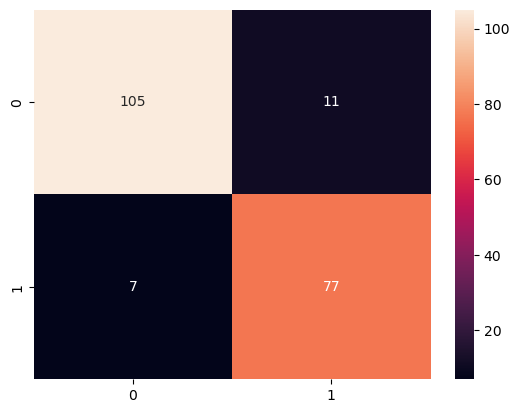

In [31]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='g')
plt.show()

In [32]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92       116
           1       0.88      0.92      0.90        84

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



In [33]:
print(f'Training Accurary: {lr.score(x_train,y_train)}')
print(f'Testing Accuray: {lr.score(x_test,y_test)}')

Training Accurary: 0.90625
Testing Accuray: 0.91


In [34]:
kf=KFold(n_splits=5)
kf_score=cross_val_score(LogisticRegression(),X,y,cv=kf)
print(kf_score)

[0.905 0.89  0.88  0.895 0.925]


In [35]:
kf_score.mean()

np.float64(0.899)

# Conclusion
 - A Logistic Regression model was developed to predict loan defaults based on applicants' demographic, financial, and credit-related information. The model achieved a training accuracy of 90.63% and a testing accuracy of 91.00%, indicating strong predictive performance and good generalization on unseen data.

 - The classification report shows that the model performs well for both classes:
 - For non-defaulted loans (Class 0), the model achieved a precision of 94%, recall of 91%, and F1-score of 92%.
 - For defaulted loans (Class 1), the model achieved a precision of 88%, recall of 92%, and F1-score of 90%.